# Support Ticket Classification & Prioritization System

"""
This project builds a machine learning system to automatically classify 
customer support tickets and assign priority levels.

It helps businesses improve response time and manage support operations efficiently.
"""


In [97]:
# importing libraries
import pandas as pd
import numpy as np
import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [98]:
# loading dataset
df = pd.read_csv(r"C:\Users\lenovo\project\dataset.csv")
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [99]:
# data understanding
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


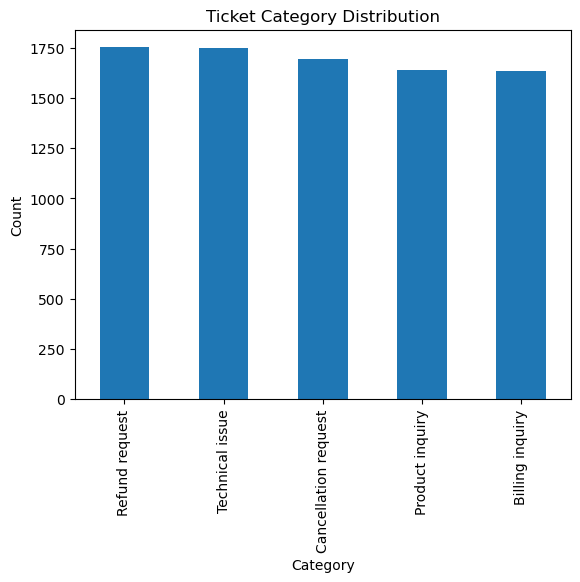

In [106]:
import matplotlib.pyplot as plt

# Category distribution
df['category'].value_counts().plot(kind='bar')
plt.title("Ticket Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

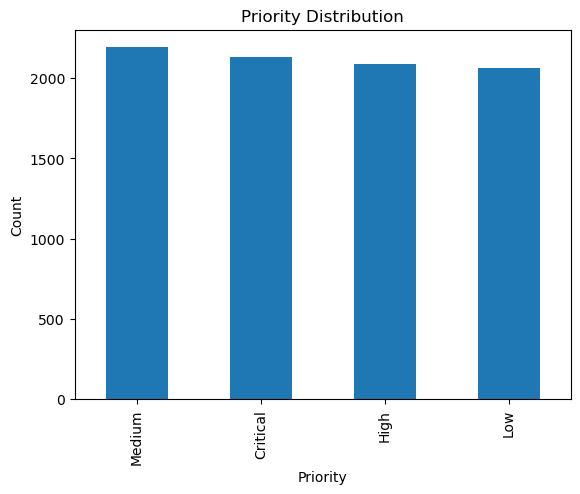

In [107]:
# Priority distribution
df['priority'].value_counts().plot(kind='bar')
plt.title("Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Count")
plt.show()

In [103]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [108]:
# renaming columns
df = df.rename(columns={
    'Ticket Description': 'ticket',
    'Ticket Type': 'category',
    'Ticket Priority': 'priority'
})

In [105]:
df[['ticket', 'category', 'priority']].head()

,ticket,category,priority
0,I'm having an issue with the {product_purchase...,Technical issue,Critical
1,I'm having an issue with the {product_purchase...,Technical issue,Critical
2,I'm facing a problem with my {product_purchase...,Technical issue,Low
3,I'm having an issue with the {product_purchase...,Billing inquiry,Low
4,I'm having an issue with the {product_purchase...,Billing inquiry,Low


In [109]:
# text processing
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['cleaned_text'] = df['ticket'].apply(preprocess)

df.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,category,Ticket Subject,ticket,Ticket Status,Resolution,priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,cleaned_text
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,issue product purchased please assist billing ...
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,issue product purchased please assist need cha...
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,facing problem product purchased product purch...
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,issue product purchased please assist problem ...
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,issue product purchased please assist note sel...


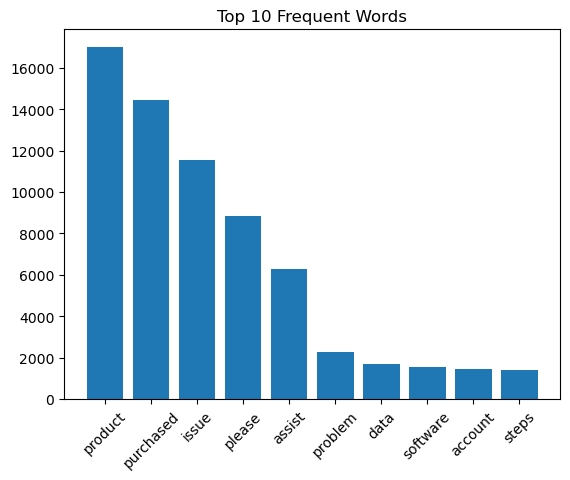

In [110]:
# word frequency visualization
from collections import Counter

all_words = " ".join(df['cleaned_text']).split()
word_freq = Counter(all_words)

common_words = dict(word_freq.most_common(10))

plt.bar(common_words.keys(), common_words.values())
plt.title("Top 10 Frequent Words")
plt.xticks(rotation=45)
plt.show()

In [111]:
# feature extraction
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['cleaned_text'])

In [112]:
# train test split
X_train, X_test, y_cat_train, y_cat_test = train_test_split(
    X, df['category'], test_size=0.2, random_state=42)

_, _, y_pri_train, y_pri_test = train_test_split(
    X, df['priority'], test_size=0.2, random_state=42)

In [113]:
# model training
cat_model = LogisticRegression()
cat_model.fit(X_train, y_cat_train)

pri_model = LogisticRegression()
pri_model.fit(X_train, y_pri_train)

LogisticRegression()

In [116]:
# predictions
cat_pred = cat_model.predict(X_test)
pri_pred = pri_model.predict(X_test)

In [115]:
# evaluation
print("Category Classification Report:\n")
print(classification_report(y_cat_test, cat_pred))

print("Priority Classification Report:\n")
print(classification_report(y_pri_test, pri_pred))

Category Classification Report:

                      precision    recall  f1-score   support

     Billing inquiry       0.18      0.13      0.15       357
Cancellation request       0.18      0.20      0.19       327
     Product inquiry       0.18      0.17      0.18       316
      Refund request       0.20      0.23      0.21       345
     Technical issue       0.22      0.23      0.22       349

            accuracy                           0.19      1694
           macro avg       0.19      0.19      0.19      1694
        weighted avg       0.19      0.19      0.19      1694

Priority Classification Report:

              precision    recall  f1-score   support

    Critical       0.24      0.25      0.25       411
        High       0.27      0.28      0.28       409
         Low       0.24      0.23      0.24       415
      Medium       0.29      0.28      0.29       459

    accuracy                           0.26      1694
   macro avg       0.26      0.26      0.26    

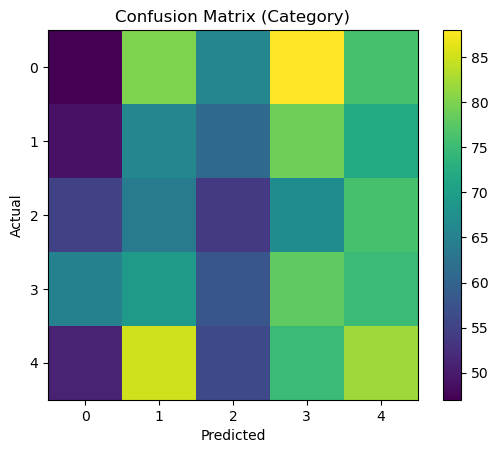

In [117]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_cat_test, cat_pred)

plt.imshow(cm)
plt.title("Confusion Matrix (Category)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()
plt.show()

In [118]:
# confusion matrix
print("Confusion Matrix (Category):")
print(confusion_matrix(y_cat_test, cat_pred))

Confusion Matrix (Category):
[[47 80 66 88 76]
 [49 66 61 79 72]
 [55 64 54 67 76]
 [65 69 58 78 75]
 [51 85 56 75 82]]


In [119]:
# test with new input
def predict_ticket(text):
    cleaned = preprocess(text)
    vector = vectorizer.transform([cleaned])
    
    category = cat_model.predict(vector)[0]
    priority = pri_model.predict(vector)[0]
    
    return category, priority

# Example
predict_ticket("Payment failed and money deducted")

('Product inquiry', 'Critical')

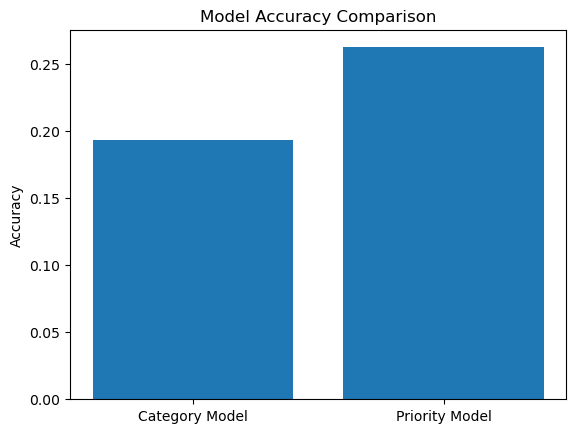

In [120]:
from sklearn.metrics import accuracy_score

cat_acc = accuracy_score(y_cat_test, cat_pred)
pri_acc = accuracy_score(y_pri_test, pri_pred)

labels = ['Category Model', 'Priority Model']
values = [cat_acc, pri_acc]

plt.bar(labels, values)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# Conclusion

"""
The system successfully classifies support tickets and assigns priority levels.

This reduces manual effort, improves response time, and enhances customer satisfaction.
Machine learning models like Logistic Regression combined with NLP techniques 
such as TF-IDF proved effective for this task.
"""